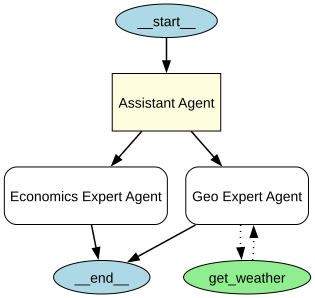

In [37]:
from agents import Agent, Runner, function_tool, SQLiteSession, trace
from agents.extensions.visualization import draw_graph
from pydantic import BaseModel

session = SQLiteSession("user_111111", "ai-memory.db")

class Answer(BaseModel):
    answer: str
    background_explanation: str

@function_tool
def get_weather():
    return "30"

geography_agent = Agent(
    name="Geo Expert Agent",
    instructions="You are a expert in geography, you answer questions related to them.",
    handoff_description="Use this to answer geography related questions.",
    tools=[get_weather],
    output_type=Answer,
)

economics_agent = Agent(
    name="Economics Expert Agent",
    instructions="You are a expert in economics, you answer questions related to them.",
    handoff_description="Use this to answer economics questions."
)

main_agent = Agent(
    name="Assistant Agent",
    instructions="You are a user facing agent. Transfer to the agent most capable of answering the user's question.",
    handoffs=[
        economics_agent, geography_agent,
    ]
)

draw_graph(main_agent)

# Tracing -> https://platform.openai.com/logs

In [ ]:
with trace("user_111111"): # Trace 별칭을 지정할 수 있음.
    result = await Runner.run(
        main_agent, 
        "What is the geographical characteristics of Seoul.", 
        session=session,
    )

    print(result.last_agent.name)
    print(result.final_output)

Geo Expert Agent
answer="Seoul, the capital city of South Korea, is located in the northwest part of the country, near the border with North Korea. It sits on the Han River, which flows through the city from east to west. The city's terrain is mostly mountainous, as it is surrounded by several mountains including Bukhansan to the north, Namsan in the center, and other ranges. While the city center and major districts are built on relatively flat river plains, the outskirts are more elevated and covered with forested hills. Seoul is part of the Gyeonggi Province region, contributing to its highly urbanized and densely populated environment." background_explanation="Seoul's geographical features have significantly influenced its history and development. Its location along the Han River made it an advantageous spot for transportation, trade, and agriculture. The surrounding mountains have historically provided natural defense barriers. The city's blend of rivers and mountains has also sha